# Data Preprocessing

# Project : Traffic Accident Risk Analysis and High-Risk Zone Identification Using Data Analytics

# Import required files:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data:

In [3]:
data = pd.read_csv(r"C:\Users\santh\Downloads\Project_dataset\Project_dataset.csv")

In [4]:
data.head(5)

,location_id,timestamp,state,road_type,lane_count,speed_limit_kmph,has_signal,enforcement_level,blackspot_score,latitude,...,red_duration_s,yellow_duration_s,cycle_time_s,violations_count,signal_data_quality_flag,accident_occurred,severity,vehicles_involved,cause,veh_count_at_accident
0,L001,2025-07-01 00:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,53.0,6.0,123.0,0.0,NaN,False,NaN,NaN,NaN,303
1,L001,2025-07-01 01:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,114.0,4.0,171.0,0.0,NaN,False,NaN,NaN,NaN,317
2,L001,2025-07-01 02:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,89.0,4.0,138.0,0.0,NaN,False,NaN,NaN,NaN,412
3,L001,2025-07-01 03:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,109.0,9.0,195.0,0.0,NaN,False,NaN,NaN,NaN,333
4,L001,2025-07-01 04:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,93.0,8.0,184.0,1.0,NaN,False,NaN,NaN,NaN,298


# Data Inspection:

In [6]:
print("(rows, columns) = ", data.shape)

(rows, columns) =  (2016, 33)


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2016 entries, 0 to 2015
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   location_id                2016 non-null   object 
 1   timestamp                  2016 non-null   object 
 2   state                      2016 non-null   object 
 3   road_type                  2016 non-null   object 
 4   lane_count                 2016 non-null   int64  
 5   speed_limit_kmph           2016 non-null   int64  
 6   has_signal                 2016 non-null   bool   
 7   enforcement_level          2016 non-null   object 
 8   blackspot_score            2016 non-null   float64
 9   latitude                   2016 non-null   float64
 10  longitude                  2016 non-null   float64
 11  season                     2016 non-null   object 
 12  day_of_week                2016 non-null   int64  
 13  hour_of_day                2016 non-null   int64

# Identifying the null values:

In [9]:
data.isna().sum()

location_id                     0
timestamp                       0
state                           0
road_type                       0
lane_count                      0
speed_limit_kmph                0
has_signal                      0
enforcement_level               0
blackspot_score                 0
latitude                        0
longitude                       0
season                          0
day_of_week                     0
hour_of_day                     0
lighting                       22
weather                        11
is_peak                         0
vehicle_count_per_hr            2
avg_speed_kmph                126
peak                            2
traffic_data_quality_flag    1984
signal_status                 672
green_duration_s              833
red_duration_s                834
yellow_duration_s             832
cycle_time_s                  834
violations_count              834
signal_data_quality_flag     2000
accident_occurred               0
severity      

In [10]:
data.columns

Index(['location_id', 'timestamp', 'state', 'road_type', 'lane_count',
       'speed_limit_kmph', 'has_signal', 'enforcement_level',
       'blackspot_score', 'latitude', 'longitude', 'season', 'day_of_week',
       'hour_of_day', 'lighting', 'weather', 'is_peak', 'vehicle_count_per_hr',
       'avg_speed_kmph', 'peak', 'traffic_data_quality_flag', 'signal_status',
       'green_duration_s', 'red_duration_s', 'yellow_duration_s',
       'cycle_time_s', 'violations_count', 'signal_data_quality_flag',
       'accident_occurred', 'severity', 'vehicles_involved', 'cause',
       'veh_count_at_accident'],
      dtype='object')

In [11]:
for col in data.columns:
    print(col, ":", data[col].unique())

location_id : ['L001' 'L002' 'L003' 'L004' 'L005' 'L006' 'L007' 'L008' 'L009' 'L010'
 'L011' 'L012']
timestamp : ['2025-07-01 00:00:00' '2025-07-01 01:00:00' '2025-07-01 02:00:00'
 '2025-07-01 03:00:00' '2025-07-01 04:00:00' '2025-07-01 05:00:00'
 '2025-07-01 06:00:00' '2025-07-01 07:00:00' '2025-07-01 08:00:00'
 '2025-07-01 09:00:00' '2025-07-01 10:00:00' '2025-07-01 11:00:00'
 '2025-07-01 12:00:00' '2025-07-01 13:00:00' '2025-07-01 14:00:00'
 '2025-07-01 15:00:00' '2025-07-01 16:00:00' '2025-07-01 17:00:00'
 '2025-07-01 18:00:00' '2025-07-01 19:00:00' '2025-07-01 20:00:00'
 '2025-07-01 21:00:00' '2025-07-01 22:00:00' '2025-07-01 23:00:00'
 '2025-07-02 00:00:00' '2025-07-02 01:00:00' '2025-07-02 02:00:00'
 '2025-07-02 03:00:00' '2025-07-02 04:00:00' '2025-07-02 05:00:00'
 '2025-07-02 06:00:00' '2025-07-02 07:00:00' '2025-07-02 08:00:00'
 '2025-07-02 09:00:00' '2025-07-02 10:00:00' '2025-07-02 11:00:00'
 '2025-07-02 12:00:00' '2025-07-02 13:00:00' '2025-07-02 14:00:00'
 '2025-07-02 15:

In [12]:
data.dtypes

location_id                   object
timestamp                     object
state                         object
road_type                     object
lane_count                     int64
speed_limit_kmph               int64
has_signal                      bool
enforcement_level             object
blackspot_score              float64
latitude                     float64
longitude                    float64
season                        object
day_of_week                    int64
hour_of_day                    int64
lighting                      object
weather                       object
is_peak                         bool
vehicle_count_per_hr         float64
avg_speed_kmph               float64
peak                          object
traffic_data_quality_flag     object
signal_status                 object
green_duration_s             float64
red_duration_s               float64
yellow_duration_s            float64
cycle_time_s                 float64
violations_count             float64
s

# Type Casting:

In [14]:
data['timestamp'] = pd.to_datetime(data['timestamp'], errors = 'coerce')
data['vehicle_count_per_hr'] = data['vehicle_count_per_hr'].astype('Int64')
data['peak'] = data['peak'].astype(bool)
data['green_duration_s'] = data['green_duration_s'].astype('Int64')
data['red_duration_s'] = data['red_duration_s'].astype('Int64')
data['yellow_duration_s'] = data['yellow_duration_s'].astype('Int64')
data['cycle_time_s'] = data['cycle_time_s'].astype('Int64')
data['violations_count'] = data['violations_count'].astype('Int64')
data['vehicles_involved'] = data['vehicles_involved'].astype('Int64')

# Converting the boolean to integer for accident_occurred column for visualization 

In [16]:
data['accident_occurred'] = data['accident_occurred'].astype(int)

In [28]:
data.dtypes

location_id                          object
timestamp                    datetime64[ns]
state                                object
road_type                            object
lane_count                            int64
speed_limit_kmph                      int64
has_signal                             bool
enforcement_level                    object
blackspot_score                     float64
latitude                            float64
longitude                           float64
season                               object
day_of_week                           int64
hour_of_day                           int64
lighting                             object
weather                              object
is_peak                                bool
vehicle_count_per_hr                  Int64
avg_speed_kmph                      float64
peak                                   bool
traffic_data_quality_flag            object
signal_status                        object
green_duration_s                

In [30]:
data

,location_id,timestamp,state,road_type,lane_count,speed_limit_kmph,has_signal,enforcement_level,blackspot_score,latitude,...,red_duration_s,yellow_duration_s,cycle_time_s,violations_count,signal_data_quality_flag,accident_occurred,severity,vehicles_involved,cause,veh_count_at_accident
0,L001,2025-07-01 00:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,53,6,123,0,NaN,0,NaN,<NA>,NaN,303
1,L001,2025-07-01 01:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,114,4,171,0,NaN,0,NaN,<NA>,NaN,317
2,L001,2025-07-01 02:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,89,4,138,0,NaN,0,NaN,<NA>,NaN,412
3,L001,2025-07-01 03:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,109,9,195,0,NaN,0,NaN,<NA>,NaN,333
4,L001,2025-07-01 04:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,93,8,184,1,NaN,0,NaN,<NA>,NaN,298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011,L012,2025-07-07 19:00:00,Telangana,urban,2,41,False,low,0.267,17.595419,...,<NA>,<NA>,<NA>,<NA>,NaN,0,NaN,<NA>,NaN,394
2012,L012,2025-07-07 20:00:00,Telangana,urban,2,41,False,low,0.267,17.595419,...,<NA>,<NA>,<NA>,<NA>,NaN,0,NaN,<NA>,NaN,657
2013,L012,2025-07-07 21:00:00,Telangana,urban,2,41,False,low,0.267,17.595419,...,<NA>,<NA>,<NA>,<NA>,NaN,0,NaN,<NA>,NaN,1612
2014,L012,2025-07-07 22:00:00,Telangana,urban,2,41,False,low,0.267,17.595419,...,<NA>,<NA>,<NA>,<NA>,NaN,0,NaN,<NA>,NaN,431


# Check the duplicate records

In [32]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2011    False
2012    False
2013    False
2014    False
2015    False
Length: 2016, dtype: bool

In [35]:
data.duplicated().sum()

0

In [37]:
data = data.drop_duplicates()

# Missing Value Analysis

In [41]:
data.isna().sum()

location_id                     0
timestamp                       0
state                           0
road_type                       0
lane_count                      0
speed_limit_kmph                0
has_signal                      0
enforcement_level               0
blackspot_score                 0
latitude                        0
longitude                       0
season                          0
day_of_week                     0
hour_of_day                     0
lighting                       22
weather                        11
is_peak                         0
vehicle_count_per_hr            2
avg_speed_kmph                126
peak                            0
traffic_data_quality_flag    1984
signal_status                 672
green_duration_s              833
red_duration_s                834
yellow_duration_s             832
cycle_time_s                  834
violations_count              834
signal_data_quality_flag     2000
accident_occurred               0
severity      

# Converting invalid(negative) values in speed column into null value

In [43]:
data.loc[data['avg_speed_kmph'] < 0, 'avg_speed_kmph'] = None

# Conditional Filling

In [47]:
data.loc[data['signal_status'].isin(['Off', 'Blinking']), 
        ['green_duration_s', 'red_duration_s', 'yellow_duration_s', 'cycle_time_s']] = 0

# Handling Null values in Numeric columns:

In [52]:
data['avg_speed_kmph'] = data['avg_speed_kmph'].fillna(data['avg_speed_kmph'].mean())
data['vehicle_count_per_hr'] = data['vehicle_count_per_hr'].fillna(round(data['vehicle_count_per_hr'].median()))

In [54]:
data['green_duration_s'] = data['green_duration_s'].fillna(round(data['green_duration_s'].mean()))
data['red_duration_s'] = data['red_duration_s'].fillna(round(data['red_duration_s'].mean()))
data['yellow_duration_s'] = data['yellow_duration_s'].fillna(round(data['yellow_duration_s'].mean()))
data['cycle_time_s'] = data['cycle_time_s'].fillna(round(data['cycle_time_s'].mean()))
data['violations_count'] = data['violations_count'].fillna(0)

# Handling Null values in Categorical Columns:

In [57]:
data['lighting'] = data['lighting'].fillna(data['lighting'].mode()[0])
data['weather'] = data['weather'].fillna(data['weather'].mode()[0])
data['signal_status'] = data['signal_status'].fillna(data['signal_status'].mode()[0])

# Accident related columns:

In [60]:
data['severity'] = data['severity'].fillna('No Accident')
data['cause'] = data['cause'].fillna('None')
data['vehicles_involved'] = data['vehicles_involved'].fillna(0)

# Data quality flag columns:

In [63]:
data['traffic_data_quality_flag'] = data['traffic_data_quality_flag'].fillna('Unknown')
data['signal_data_quality_flag'] = data['signal_data_quality_flag'].fillna('Unknown')

In [65]:
data.isna().sum()

location_id                  0
timestamp                    0
state                        0
road_type                    0
lane_count                   0
speed_limit_kmph             0
has_signal                   0
enforcement_level            0
blackspot_score              0
latitude                     0
longitude                    0
season                       0
day_of_week                  0
hour_of_day                  0
lighting                     0
weather                      0
is_peak                      0
vehicle_count_per_hr         0
avg_speed_kmph               0
peak                         0
traffic_data_quality_flag    0
signal_status                0
green_duration_s             0
red_duration_s               0
yellow_duration_s            0
cycle_time_s                 0
violations_count             0
signal_data_quality_flag     0
accident_occurred            0
severity                     0
vehicles_involved            0
cause                        0
veh_coun

In [67]:
data.describe()

,timestamp,lane_count,speed_limit_kmph,blackspot_score,latitude,longitude,day_of_week,hour_of_day,vehicle_count_per_hr,avg_speed_kmph,green_duration_s,red_duration_s,yellow_duration_s,cycle_time_s,violations_count,accident_occurred,vehicles_involved,veh_count_at_accident
count,2016,2016.000000,2016.000000,2016.00000,2016.000000,2016.000000,2016.000000,2016.000000,2016.0,2016.000000,2016.0,2016.0,2016.0,2016.0,2016.0,2016.000000,2016.0,2016.000000
mean,2025-07-04 11:30:00,3.000000,62.666667,0.21625,17.404106,78.471091,3.000000,11.500000,1043.092758,31.012189,52.753968,66.933036,5.168155,124.889385,0.513393,0.046131,0.146825,1043.560516
min,2025-07-01 00:00:00,1.000000,41.000000,0.00600,17.258487,78.272288,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
25%,2025-07-02 17:45:00,2.000000,48.500000,0.12200,17.307465,78.351398,1.000000,5.750000,384.0,15.100000,46.0,57.0,4.0,121.0,0.0,0.000000,0.0,383.750000
50%,2025-07-04 11:30:00,2.000000,53.500000,0.22500,17.397346,78.473841,3.000000,11.500000,652.0,24.800000,53.0,67.0,5.0,125.0,0.0,0.000000,0.0,651.500000
75%,2025-07-06 05:15:00,4.000000,61.000000,0.26725,17.487200,78.533472,5.000000,17.250000,1198.25,35.825000,65.0,83.0,6.0,149.0,1.0,0.000000,0.0,1199.250000
max,2025-07-07 23:00:00,8.000000,119.000000,0.60500,17.595419,78.829084,6.000000,23.000000,18490.0,216.000000,120.0,120.0,65.0,235.0,5.0,1.000000,10.0,18490.000000
std,NaN,1.779955,23.498144,0.14814,0.103517,0.153438,2.000496,6.923904,1203.284501,24.144523,22.692047,28.688538,3.898845,45.716617,0.864416,0.209821,0.791562,1203.554704


In [69]:
data

,location_id,timestamp,state,road_type,lane_count,speed_limit_kmph,has_signal,enforcement_level,blackspot_score,latitude,...,red_duration_s,yellow_duration_s,cycle_time_s,violations_count,signal_data_quality_flag,accident_occurred,severity,vehicles_involved,cause,veh_count_at_accident
0,L001,2025-07-01 00:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,53,6,123,0,Unknown,0,No Accident,0,None,303
1,L001,2025-07-01 01:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,114,4,171,0,Unknown,0,No Accident,0,None,317
2,L001,2025-07-01 02:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,89,4,138,0,Unknown,0,No Accident,0,None,412
3,L001,2025-07-01 03:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,109,9,195,0,Unknown,0,No Accident,0,None,333
4,L001,2025-07-01 04:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,93,8,184,1,Unknown,0,No Accident,0,None,298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011,L012,2025-07-07 19:00:00,Telangana,urban,2,41,False,low,0.267,17.595419,...,67,5,125,0,Unknown,0,No Accident,0,None,394
2012,L012,2025-07-07 20:00:00,Telangana,urban,2,41,False,low,0.267,17.595419,...,67,5,125,0,Unknown,0,No Accident,0,None,657
2013,L012,2025-07-07 21:00:00,Telangana,urban,2,41,False,low,0.267,17.595419,...,67,5,125,0,Unknown,0,No Accident,0,None,1612
2014,L012,2025-07-07 22:00:00,Telangana,urban,2,41,False,low,0.267,17.595419,...,67,5,125,0,Unknown,0,No Accident,0,None,431


# Save the Dataset

In [150]:
data.to_csv(r"C:\Users\santh\Downloads\Processed_Traffic_dataset.csv", index = False)
print("Process Completed")

Process Completed


In [71]:
data = pd.read_csv(r"C:\Users\santh\Downloads\Processed_Traffic_dataset.csv")

In [73]:
data.head(5)

,location_id,timestamp,state,road_type,lane_count,speed_limit_kmph,has_signal,enforcement_level,blackspot_score,latitude,...,red_duration_s,yellow_duration_s,cycle_time_s,violations_count,signal_data_quality_flag,accident_occurred,severity,vehicles_involved,cause,veh_count_at_accident
0,L001,2025-07-01 00:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,53,6,123,0,Unknown,0,No Accident,0,NaN,303
1,L001,2025-07-01 01:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,114,4,171,0,Unknown,0,No Accident,0,NaN,317
2,L001,2025-07-01 02:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,89,4,138,0,Unknown,0,No Accident,0,NaN,412
3,L001,2025-07-01 03:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,109,9,195,0,Unknown,0,No Accident,0,NaN,333
4,L001,2025-07-01 04:00:00,Telangana,urban,2,47,True,low,0.318,17.314579,...,93,8,184,1,Unknown,0,No Accident,0,NaN,298


# Traffic Density

In [75]:
data['Traffic_density'] = data['vehicle_count_per_hr'] / data['lane_count']

In [76]:
data['Traffic_density']

0       151.5
1       158.5
2       206.0
3       166.5
4       149.0
        ...  
2011    197.0
2012    328.5
2013    806.0
2014    215.5
2015    249.0
Name: Traffic_density, Length: 2016, dtype: float64

# High Risk Zones:

In [78]:
high_risk = data.groupby('location_id')['blackspot_score'].mean().reset_index()

In [79]:
high_risk = high_risk.sort_values(by = 'blackspot_score', ascending = False)

In [80]:
high_risk.head(10)

,location_id,blackspot_score
7,L008,0.605
0,L001,0.318
8,L009,0.268
11,L012,0.267
5,L006,0.247
4,L005,0.228
6,L007,0.222
1,L002,0.146
2,L003,0.127
10,L011,0.107


# Feature Engineering

In [83]:
# Traffic Density:

data['traffic_density'] = data['vehicle_count_per_hr'] / data['lane_count']

In [84]:
data['timestamp'] = pd.to_datetime(data['timestamp'], errors = 'coerce')

In [85]:
# Peak Hour (8-10 AM, 5-7 PM)

data['hour'] = data['timestamp'].dt.hour
data['peak_hour'] = data['hour'].isin([8,9,17,18]).astype(int)

# Risk Score Calculation

In [88]:
data['risk_score'] = (
    0.3 * data['traffic_density']+                # Traffic density contributes 30% of total risk
    0.2 * data['speed_limit_kmph']+               # Speed contributes 20% of total risk
    0.2 * data['blackspot_score']+                # History contributes 20% of risk
    0.1 * data['is_peak']+                        # Time contributes 10% only
    0.2 * data['accident_occurred']               # Real accident data contributes 20%
)

In [89]:
data['risk_score']

0        54.9136
1        57.0136
2        71.2636
3        59.4136
4        54.1636
          ...   
2011     67.4534
2012    106.9034
2013    250.1534
2014     72.9034
2015     82.9534
Name: risk_score, Length: 2016, dtype: float64

In [101]:
high_risk = data.groupby('location_id')['risk_score'].mean().reset_index()

In [103]:
high_risk = high_risk.sort_values(by = 'risk_score', ascending = False)

In [105]:
high_risk.head(10)

,location_id,risk_score
9,L010,191.771140
6,L007,153.164117
10,L011,116.464555
8,L009,115.546457
11,L012,108.696852
1,L002,106.105688
5,L006,105.461007
0,L001,102.926100
3,L004,88.582229
2,L003,87.623019


# Accidents by hour:

In [109]:
accidents_by_hour = data.groupby('hour')['accident_occurred'].sum()

In [111]:
accidents_by_hour

hour
0     5
1     4
2     4
3     7
4     4
5     0
6     3
7     0
8     7
9     2
10    4
11    3
12    4
13    1
14    1
15    1
16    5
17    4
18    5
19    6
20    7
21    6
22    7
23    3
Name: accident_occurred, dtype: int64

# Exploratory Data Analysis:

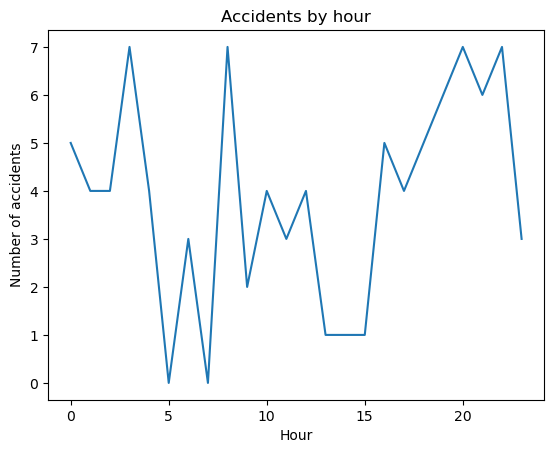

In [114]:
# Accidents by hour

plt.figure()
accidents_by_hour.plot()
plt.title("Accidents by hour")
plt.xlabel('Hour')
plt.ylabel('Number of accidents')
plt.show()

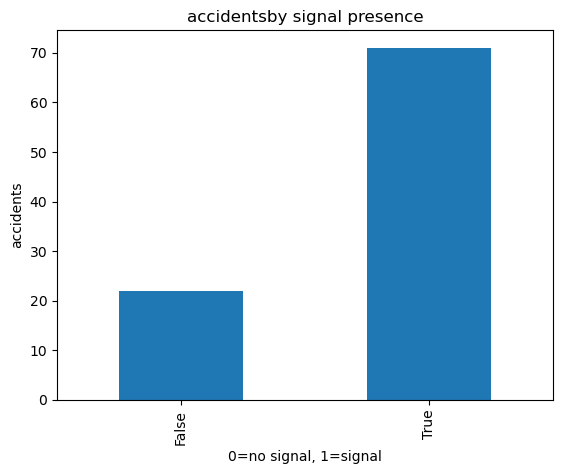

In [115]:
# Accidents by signal status

plt.figure()
data.groupby('has_signal')['accident_occurred'].sum().plot(kind = 'bar')
plt.title('accidentsby signal presence')
plt.xlabel('0=no signal, 1=signal')
plt.ylabel('accidents')
plt.show()